# LPBO-DRNet Experiment 1 — SEED=42 · BndFocal γ=2.0 · Boost Boundary Weights [2.00,2.50,2.00,1.50]

**New vs RS_21**: Stronger adjacent boundary focus to fix Moderate↔Mild/Prolif confusion.
`BOUNDARY_FOCAL_GAMMA=2.0` (up from 1.5), weights `[2.00, 2.50, 2.00, 1.50]` (boost 1↔2 and 2↔3).
All RS_21 best settings: `LR_BACKBONE=5e-5`, `EMA_DECAY=0.9995`, `PLATEAU_PATIENCE=6`, `ES=15`.


In [1]:
# ==============================================
# CELL 1 - Imports + Config
# ==============================================
import os, sys, math, time, random, warnings, hashlib
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import transforms
import torchvision.models as tv_models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    cohen_kappa_score, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ───────────────────────────
SEED        = 42
NUM_CLASSES = 5
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

# ── Dataset mode: uncomment exactly one mode ─────────────────────────────
# DATA_MODE = "aptos_only"
# DATA_MODE = "messidor_only"
# DATA_MODE = "aptos_gan"
DATA_MODE = "messidor_gan"
VALID_DATA_MODES = {'aptos_only', 'messidor_only', 'aptos_gan', 'messidor_gan'}
if DATA_MODE not in VALID_DATA_MODES:
    raise ValueError(f'Invalid DATA_MODE={DATA_MODE!r}. Choose one of {sorted(VALID_DATA_MODES)}')

# ── Backbone variant ──────────────────────────
BACKBONE_FAMILY = "lpbo_effv2s"
BACKBONE_DISPLAY_NAME = "LPBO-DRNet / EfficientNetV2-S"
TIMM_MODEL_CANDIDATES = []

# ── Image / batch ─────────────────────────────
IMAGE_SIZE  = 320      # keep LPBO best config
BATCH_SIZE  = 16
NUM_WORKERS = 2

# ── Training ─────────────────────────────────
MAX_EPOCHS              = 120
EARLY_STOPPING_PATIENCE = 15   # RS_21 proven best
# ── Phase 2: Real-only Fine-tune ───────────────────────────
REAL_FINETUNE_EPOCHS   = 10    # max epochs of real-only fine-tuning
LR_BACKBONE_P2         = 3e-6  # ultra-low backbone LR for phase 2
LR_HEAD_P2             = 1.5e-5  # ultra-low head LR for phase 2
P2_PATIENCE            = 5     # early stopping patience for phase 2

GRAD_CLIP_NORM          = 1.0

# ── Learning rates ────────────────────────────
LR_BACKBONE  = 5e-5    # RS_21 proven best
LR_HEAD      = 3e-4    # RS_21 proven best
WEIGHT_DECAY = 1e-4

# ── Loss params ───────────────────────────────
FOCAL_GAMMA      = 2.0
LABEL_SMOOTHING  = 0.0   # reverted — label smoothing was harmful in RS_20
ORDINAL_RANK_WEIGHT = 0.40  # BCE=0.60, rank focal=0.40

# ── Cascaded Head params ──────────────────────
PROJ_DIM       = 256
NUM_SUPER_TOKENS = 16
NUM_HEADS      = 8
SA_LAYERS      = 2
HEAD_DROPOUT   = 0.10   # reverted — dropout 0.20 was harmful in RS_20
DROP_PATH_RATE = 0.10

# ── Lesion Pyramid Tokenizer ──────────────────
# For EfficientNetV2-S this is the original LPBO best tap set.
# For timm backbones, channels are read from feature_info at runtime.
PYRAMID_STAGE_IDS      = (3, 4, 6)
PYRAMID_STAGE_CHANNELS = (64, 128, 256)
PYRAMID_TOPK           = (12, 12, 8)
PYRAMID_SCORE_TEMP     = 0.70

# ── Boundary-Aware Ordinal Head ───────────────
BOUNDARY_LOSS_WEIGHT = 0.40
BOUNDARY_PAIR_WEIGHTS = [2.00, 2.50, 2.00, 1.50]  # boosted: 1↔2 and 2↔3 for Moderate confusion fix
BOUNDARY_FOCAL_GAMMA = 2.0  # Stronger focal: harder weight on boundary errors
BAO_CORRECTION_MODE = 'aggressive'
BAO_MARGIN = 0.32
BAO_CONFIDENCE = 0.96

# ── Dual decision / prototype auxiliary ───────
CE_AUX_WEIGHT = 0.12
PROTOTYPE_AUX_WEIGHT = 0.08
PROTOTYPE_TEMPERATURE = 0.20

# ── Scheduler ─────────────────────────────────
PLATEAU_FACTOR   = 0.5
PLATEAU_PATIENCE = 6    # RS_21 proven best
MIN_LR           = 1e-6

# -- Validation-selected checkpoint ensemble --
ENSEMBLE_TOP_N   = 5    # RS_21 proven best
ENSEMBLE_MAX_SIZE = 5

# ── EMA / ordinal threshold tuning ─────────────
USE_EMA    = True
EMA_DECAY  = 0.9995  # slower EMA → more stable model average
THRESHOLD_TUNE_METRIC = 'qwk'

# ── Paths ─────────────────────────────────────
RUN_NAME = f'{BACKBONE_FAMILY}_{DATA_MODE}_bndfocal_g{BOUNDARY_FOCAL_GAMMA}_bw250_seed{SEED}'
OUTPUT_DIR      = Path('/kaggle/working') / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = OUTPUT_DIR / 'selected_primary.pt'
BEST_LOSS_PATH  = OUTPUT_DIR / 'best_val_loss.pt'
BEST_ACC_PATH   = OUTPUT_DIR / 'best_val_acc.pt'
BEST_QWK_PATH   = OUTPUT_DIR / 'best_val_qwk.pt'

APTOS_ROOT_CANDIDATES = [
    Path('/kaggle/input/competitions/aptos2019-blindness-detection'),
    Path('/kaggle/input/aptos2019-blindness-detection'),
    Path('data/aptos2019-blindness-detection 2'),
]
APTOS_GAN_ROOT_CANDIDATES = [
    Path('/kaggle/input/datasets/phuclenguyen/gan-data/GAN_Data_APTOS'),
    Path('/kaggle/input/datasets/phanthinan/aptos-gan/GAN_Data_APTOS'),
    Path('/kaggle/input/datasets/annindie/gan-aptos-data/GAN_Data_APTOS'),
    Path('/kaggle/input/datasets/hongthuy68/gan-data/GAN_Data_APTOS'),
]
MESSIDOR_ROOT_CANDIDATES = [
    Path('/kaggle/input/datasets/mainguynthanht/messidor/Messidor'),
    Path('/kaggle/input/datasets/mainguynthanht/messidor/Messidor/Messidor'),
    Path('/kaggle/input/messidor/Messidor'),
    Path('/kaggle/input/datasets/annindie/messidor/Messidor'),
    Path('/kaggle/input/datasets/annindie/messidor/Messidor'),
]
MESSIDOR_GAN_ROOT_CANDIDATES = [
    Path('/kaggle/input/datasets/annindie/gan-messidor/GAN_Data_MESSIDOR'),
    Path('/kaggle/input/datasets/mainguynthanht/gan-messidor/GAN_Data_MESSIDOR/GAN_Data_MESSIDOR'),
    Path('/kaggle/input/datasets/annindie/gan-messidor/GAN_Data_MESSIDOR'),
    Path('/kaggle/input/datasets/hongthuy68/gan-messidor/GAN_Data_MESSIDOR')
]

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print('Python:', sys.version)
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
print('Device:', device)
print('DATA_MODE:', DATA_MODE)
print('Backbone:', BACKBONE_DISPLAY_NAME)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Device: cuda
DATA_MODE: messidor_gan
Backbone: LPBO-DRNet / EfficientNetV2-S


In [2]:
# ==============================================
# CELL 2 - Utilities
# ==============================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(SEED)

try:
    from torch.cuda.amp import autocast as _autocast, GradScaler as _GradScaler
except Exception:
    _autocast = _GradScaler = None

class _NullScaler:
    def scale(self, loss):   return loss
    def unscale_(self, opt): pass
    def step(self, opt):     opt.step()
    def update(self):        pass

def amp_autocast():
    if USE_AMP and _autocast is not None:
        return _autocast()
    import contextlib
    return contextlib.nullcontext()

def make_scaler():
    return _GradScaler() if USE_AMP and _GradScaler is not None else _NullScaler()

def safe_torch_load(path, map_location='cpu'):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

print('Utilities ready.')


Utilities ready.


In [3]:
# ==============================================
# CELL 3 - Load APTOS/Messidor + optional GAN, Clean Real Data, Split 60/20/20
# ==============================================
IMG_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}


def first_existing(candidates, check_fn, name):
    for root in candidates:
        if check_fn(root):
            return root
    raise FileNotFoundError(f'{name} not found in: ' + ', '.join(map(str, candidates)))


def find_aptos_root():
    return first_existing(
        APTOS_ROOT_CANDIDATES,
        lambda root: (root / 'train.csv').exists() and (root / 'train_images').is_dir(),
        'APTOS')


def find_messidor_root():
    return first_existing(
        MESSIDOR_ROOT_CANDIDATES,
        lambda root: (root / 'messidor_data.csv').exists() and (root / 'messidor-2' / 'messidor-2' / 'preprocess').is_dir(),
        'MESSIDOR')


def find_gan_root(candidates, name):
    def valid(root):
        if not root.exists() or not root.is_dir():
            return False
        return any((root / str(cls)).is_dir() for cls in range(NUM_CLASSES))
    return first_existing(candidates, valid, name)


def file_sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()


def load_aptos_raw():
    root = find_aptos_root()
    df = pd.read_csv(root / 'train.csv')
    df['image_path'] = df['id_code'].apply(lambda x: str(root / 'train_images' / f'{x}.png'))
    df['label'] = df['diagnosis'].astype(int)
    df['source'] = 'aptos'
    missing = (~df['image_path'].apply(lambda p: Path(p).exists())).sum()
    if missing:
        raise FileNotFoundError(f'Missing {missing} APTOS images')
    df['image_hash'] = df['image_path'].apply(file_sha256)
    print(f'APTOS raw rows: {len(df)}')
    print(df['label'].value_counts().sort_index())
    return df[['image_path', 'label', 'source', 'id_code', 'image_hash']]


def load_messidor_raw():
    root = find_messidor_root()
    img_dir = root / 'messidor-2' / 'messidor-2' / 'preprocess'
    df = pd.read_csv(root / 'messidor_data.csv')
    if 'adjudicated_gradable' in df.columns:
        before = len(df)
        df = df[df['adjudicated_gradable'].fillna(0).astype(int) == 1].reset_index(drop=True)
        print(f'Messidor gradable filter: {before} -> {len(df)}')
    df['id_code'] = df['id_code'].astype(str)
    df['image_path'] = df['id_code'].apply(lambda x: str(img_dir / x))
    df['label'] = df['diagnosis'].astype(int)
    df['source'] = 'messidor'
    missing = (~df['image_path'].apply(lambda p: Path(p).exists())).sum()
    if missing:
        examples = df.loc[~df['image_path'].apply(lambda p: Path(p).exists()), 'image_path'].head(5).tolist()
        raise FileNotFoundError(f'Missing {missing} Messidor images. Examples: {examples}')
    df['image_hash'] = df['image_path'].apply(file_sha256)
    print(f'Messidor raw rows: {len(df)}')
    print(df['label'].value_counts().sort_index())
    return df[['image_path', 'label', 'source', 'id_code', 'image_hash']]


def clean_real_by_hash(df, dataset_name):
    label_nunique = df.groupby('image_hash')['label'].nunique()
    conflict_hashes = set(label_nunique[label_nunique > 1].index)
    conflict_files = int(df['image_hash'].isin(conflict_hashes).sum())
    no_conflict = df[~df['image_hash'].isin(conflict_hashes)].copy()
    before_collapse = len(no_conflict)
    clean = (no_conflict.sort_values(['image_hash', 'id_code'])
             .drop_duplicates('image_hash', keep='first')
             .reset_index(drop=True))
    collapsed_files = before_collapse - len(clean)
    print(f'\n{dataset_name} SHA-cleaning:')
    print(f'  unique raw hashes           : {df["image_hash"].nunique()}')
    print(f'  conflict hash groups dropped: {len(conflict_hashes)}')
    print(f'  conflict files dropped      : {conflict_files}')
    print(f'  same-label duplicates merged: {collapsed_files}')
    print(f'  clean rows                  : {len(clean)}')
    print(clean['label'].value_counts().sort_index())
    return clean, conflict_hashes


def load_gan(candidates, source_name):
    root = find_gan_root(candidates, source_name)
    rows = []
    for cls in range(NUM_CLASSES):
        d = root / str(cls)
        if not d.is_dir():
            continue
        for p in sorted(d.rglob('*')):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                rows.append({'image_path': str(p), 'label': cls,
                             'source': source_name.lower(), 'id_code': p.stem,
                             'image_hash': f'{source_name.lower()}::{cls}::{p.stem}'})
    df = pd.DataFrame(rows)
    if df.empty:
        df = pd.DataFrame(columns=['image_path', 'label', 'source', 'id_code', 'image_hash'])
    print(f'\n{source_name} root: {root}')
    print(f'{source_name} rows: {len(df)}')
    if len(df):
        print(df['label'].value_counts().sort_index())
    return df


if DATA_MODE.startswith('aptos'):
    real_raw = load_aptos_raw()
    real_df, conflict_hashes = clean_real_by_hash(real_raw, 'APTOS')
    dataset_name = 'APTOS'
elif DATA_MODE.startswith('messidor'):
    real_raw = load_messidor_raw()
    real_df, conflict_hashes = clean_real_by_hash(real_raw, 'Messidor')
    dataset_name = 'Messidor'
else:
    raise ValueError(f'Unsupported DATA_MODE={DATA_MODE}')

use_gan = DATA_MODE in {'aptos_gan', 'messidor_gan'}
if use_gan and DATA_MODE == 'aptos_gan':
    gan_df = load_gan(APTOS_GAN_ROOT_CANDIDATES, 'GAN_APTOS')
elif use_gan and DATA_MODE == 'messidor_gan':
    gan_df = load_gan(MESSIDOR_GAN_ROOT_CANDIDATES, 'GAN_MESSIDOR')
else:
    gan_df = pd.DataFrame(columns=['image_path', 'label', 'source', 'id_code', 'image_hash'])
    print('\nGAN disabled for DATA_MODE:', DATA_MODE)

train_real, temp = train_test_split(
    real_df, test_size=0.40, random_state=SEED, stratify=real_df['label'])
val_real, test_real = train_test_split(
    temp, test_size=0.50, random_state=SEED, stratify=temp['label'])
train_real = train_real.reset_index(drop=True)
val_real = val_real.reset_index(drop=True)
test_real = test_real.reset_index(drop=True)

train_hashes = set(train_real['image_hash'])
val_hashes = set(val_real['image_hash'])
test_hashes = set(test_real['image_hash'])
assert train_hashes.isdisjoint(val_hashes)
assert train_hashes.isdisjoint(test_hashes)
assert val_hashes.isdisjoint(test_hashes)
assert train_real['image_hash'].is_unique
assert val_real['image_hash'].is_unique
assert test_real['image_hash'].is_unique

print('\nClean split:')
for n, d in [('train_real', train_real), ('val', val_real), ('test', test_real)]:
    print(f'  {n}: {len(d)}', d['label'].value_counts().sort_index().to_dict())
print('  hash crossing: none')


Messidor gradable filter: 1744 -> 1744
Messidor raw rows: 1744
label
0    1017
1     270
2     347
3      75
4      35
Name: count, dtype: int64

Messidor SHA-cleaning:
  unique raw hashes           : 1740
  conflict hash groups dropped: 0
  conflict files dropped      : 0
  same-label duplicates merged: 4
  clean rows                  : 1740
label
0    1017
1     268
2     345
3      75
4      35
Name: count, dtype: int64

GAN_MESSIDOR root: /kaggle/input/datasets/annindie/gan-messidor/GAN_Data_MESSIDOR
GAN_MESSIDOR rows: 3273
label
1    730
2    653
3    925
4    965
Name: count, dtype: int64

Clean split:
  train_real: 1044 {0: 610, 1: 161, 2: 207, 3: 45, 4: 21}
  val: 348 {0: 203, 1: 54, 2: 69, 3: 15, 4: 7}
  test: 348 {0: 204, 1: 53, 2: 69, 3: 15, 4: 7}
  hash crossing: none


In [4]:
# ==============================================
# CELL 4 - Build Train/Val/Test Manifest
# train = clean real train (+ GAN when DATA_MODE uses GAN)
# val/test = clean real only.
# ==============================================

def build_train_manifest(train_real, gan_df):
    parts = [train_real.copy()]
    if len(gan_df):
        parts.append(gan_df.copy())
    train_df = pd.concat(parts, ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

    real_counts = train_real['label'].value_counts().sort_index().to_dict()
    gan_counts = gan_df['label'].value_counts().sort_index().to_dict() if len(gan_df) else {}
    plan = []
    for cls in range(NUM_CLASSES):
        real_n = int(real_counts.get(cls, 0))
        gan_n = int(gan_counts.get(cls, 0))
        plan.append((cls, real_n, gan_n, real_n + gan_n))
    plan_df = pd.DataFrame(plan, columns=['class', 'real', 'gan_used', 'total'])
    return train_df, plan_df


train_df, plan_df = build_train_manifest(train_real, gan_df)
val_df = val_real.copy().reset_index(drop=True)
test_df = test_real.copy().reset_index(drop=True)


# Official clean-test protocol: no sample is removed after splitting.
# Model selection uses validation data only.
assert len(test_df) == len(test_real)
print(f'Official clean test retained in full: {len(test_df)} images')

protocol = f'{dataset_name} clean real train'
if len(gan_df):
    protocol += ' + GAN train images'
protocol += '; val/test = clean real only'
print(f'DATA_MODE protocol: {protocol}')
print(plan_df.to_string(index=False))
print('\nFinal train dist:', train_df['label'].value_counts().sort_index().to_dict())
print('Source counts:', train_df['source'].value_counts().to_dict())
print('Val dist:', val_df['label'].value_counts().sort_index().to_dict())
print('Test dist:', test_df['label'].value_counts().sort_index().to_dict())

train_df.to_csv(OUTPUT_DIR / f'train_{DATA_MODE}.csv', index=False)
val_df.to_csv(OUTPUT_DIR / f'val_{DATA_MODE}.csv', index=False)
test_df.to_csv(OUTPUT_DIR / f'test_{DATA_MODE}.csv', index=False)


Official clean test retained in full: 348 images
DATA_MODE protocol: Messidor clean real train + GAN train images; val/test = clean real only
 class  real  gan_used  total
     0   610         0    610
     1   161       730    891
     2   207       653    860
     3    45       925    970
     4    21       965    986

Final train dist: {0: 610, 1: 891, 2: 860, 3: 970, 4: 986}
Source counts: {'gan_messidor': 3273, 'messidor': 1044}
Val dist: {0: 203, 1: 54, 2: 69, 3: 15, 4: 7}
Test dist: {0: 204, 1: 53, 2: 69, 3: 15, 4: 7}


In [5]:
# ==============================================
# CELL 5 - Dataset + Letterbox Pad + Conservative Augmentation
# No CLAHE, Ben Graham, MixUp, CutMix. No crop.
# ==============================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class LetterboxPad:
    """Resize while preserving aspect ratio, then pad to a square canvas."""
    def __init__(self, size, fill=(0, 0, 0)):
        self.size = int(size)
        self.fill = fill

    def __call__(self, img):
        w, h = img.size
        scale = self.size / max(w, h)
        nw = max(1, int(round(w * scale)))
        nh = max(1, int(round(h * scale)))
        img = img.resize((nw, nh), Image.Resampling.BILINEAR)
        canvas = Image.new('RGB', (self.size, self.size), self.fill)
        canvas.paste(img, ((self.size - nw) // 2, (self.size - nh) // 2))
        return canvas


# Conservative source-aware augmentation: keep tiny DR lesions sharp and avoid crop.
real_train_tfms = transforms.Compose([
    LetterboxPad(IMAGE_SIZE, fill=(0, 0, 0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.20),
    transforms.RandomRotation(degrees=10, fill=0),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.06, hue=0.015),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# GAN images are already 256x256 synthetic retina images; use lighter color/geometry jitter.
gan_train_tfms = transforms.Compose([
    LetterboxPad(IMAGE_SIZE, fill=(0, 0, 0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(degrees=7, fill=0),
    transforms.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.04, hue=0.01),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

valid_tfms = transforms.Compose([
    LetterboxPad(IMAGE_SIZE, fill=(0, 0, 0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class DRDataset(Dataset):
    def __init__(self, df, mode='train'):
        self.df = df.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def _select_transform(self, row):
        if self.mode != 'train':
            return valid_tfms
        if str(row.get('source', '')).lower().startswith('gan') or row.get('source') == 'acfd_gan':
            return gan_train_tfms
        return real_train_tfms

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        img = self._select_transform(row)(img)
        label = int(row['label'])
        return img, torch.tensor(label, dtype=torch.long)


train_ds = DRDataset(train_df, mode='train')
val_ds   = DRDataset(val_df,   mode='valid')
test_ds  = DRDataset(test_df,  mode='valid')

def seed_worker(worker_id):
    worker_seed = (SEED + worker_id) % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
    worker_init_fn=seed_worker, generator=loader_generator)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    worker_init_fn=seed_worker, generator=loader_generator)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    worker_init_fn=seed_worker, generator=loader_generator)

print('DataLoaders ready:')
print(f'  train: {len(train_loader)} batches')
print(f'  val  : {len(val_loader)} batches')
print(f'  test : {len(test_loader)} batches')
print('Transform: LetterboxPad + conservative source-aware augmentation')


DataLoaders ready:
  train: 270 batches
  val  : 22 batches
  test : 22 batches
Transform: LetterboxPad + conservative source-aware augmentation


In [6]:
# ==============================================
# CELL 6 - Architecture: Building Blocks
# DropPath | GeMPool | CrossAttentionCompressor
# ==============================================

# ── DropPath ─────────────────────────────────
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training: return x
        kp    = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.dim() - 1)
        mask  = torch.floor(torch.rand(shape, dtype=x.dtype, device=x.device) + kp)
        return x.div(kp) * mask


# ── FFN helper ───────────────────────────────
def make_ffn(dim, expand=4, dropout=0.1):
    return nn.Sequential(
        nn.Linear(dim, dim * expand),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(dim * expand, dim),
        nn.Dropout(dropout),
    )


# ── Cross-Attention Compressor ────────────────
# Inspired by Perceiver IO: compress N spatial tokens → K super-tokens
# using K learnable query vectors attending over the N spatial tokens.
class CrossAttentionCompressor(nn.Module):
    """
    Perceiver-inspired compression:
      Input : (B, N, C)  — N spatial tokens from backbone
      Output: (B, K, C)  — K compressed super-tokens
    K << N reduces sequence length before self-attention.
    """
    def __init__(self, embed_dim, num_super_tokens=16,
                 num_heads=8, dropout=0.1, drop_path=0.0):
        super().__init__()
        self.queries = nn.Parameter(
            torch.empty(1, num_super_tokens, embed_dim))
        nn.init.trunc_normal_(self.queries, std=0.02)

        self.norm_q  = nn.LayerNorm(embed_dim)
        self.norm_kv = nn.LayerNorm(embed_dim)
        self.cross   = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.dp      = DropPath(drop_path) if drop_path > 0 else nn.Identity()
        self.ffn     = make_ffn(embed_dim, dropout=dropout)
        self.norm_ff = nn.LayerNorm(embed_dim)

    def forward(self, x):           # x: (B, N, C)
        B = x.shape[0]
        q = self.queries.expand(B, -1, -1)          # (B, K, C)
        out, _ = self.cross(self.norm_q(q),
                            self.norm_kv(x),
                            self.norm_kv(x))
        q  = q + self.dp(out)                       # residual
        q  = q + self.dp(self.ffn(self.norm_ff(q)))
        return q                                    # (B, K, C)


# ── Frank & Hall Ordinal Head ─────────────────
# Ordinal regression: K-1 binary classifiers P(y > k)
# Ref: Frank & Hall, "A Simple Approach to Ordinal Classification" (2001)
class OrdinalHead(nn.Module):
    """
    Output K-1 binary logits for P(y > 0), P(y > 1), ..., P(y > K-2).
    `forward()` accepts feature embeddings. `logits_to_proba()` accepts the
    already-computed ordinal logits and converts them into a normalized
    5-class probability tensor for metrics and auxiliary losses.
    """
    def __init__(self, in_features, num_classes, dropout=0.0):
        super().__init__()
        self.K  = num_classes
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes - 1)
        )

    def forward(self, x):
        """Feature embeddings (B, C) -> raw binary logits (B, K-1)."""
        return self.fc(x)

    def logits_to_proba(self, binary_logits):
        """Ordinal logits (B, K-1) -> normalized class probabilities (B, K)."""
        p_gt = torch.sigmoid(binary_logits)         # P(y > k), shape (B, K-1)
        ones  = torch.ones(binary_logits.size(0), 1, device=binary_logits.device)
        zeros = torch.zeros(binary_logits.size(0), 1, device=binary_logits.device)
        cdf   = torch.cat([ones, p_gt, zeros], dim=1)
        probs = cdf[:, :-1] - cdf[:, 1:]
        probs = torch.clamp(probs, min=1e-7)
        return probs / probs.sum(dim=1, keepdim=True).clamp_min(1e-7)

    def predict_class(self, x):
        """Feature embeddings (B, C) -> normalized class probabilities (B, K)."""
        return self.logits_to_proba(self.forward(x))


print('Building blocks defined: DropPath, CrossAttentionCompressor, OrdinalHead')


Building blocks defined: DropPath, CrossAttentionCompressor, OrdinalHead


In [7]:
# ==============================================
# CELL 7 - Full Model: LPBO-DRNet / EfficientNetV2-S + Lesion Pyramid Tokenizer
#          + Boundary-Conditioned Fusion + BAO Aggressive
# ==============================================

class BoundaryHead(nn.Module):
    """Binary specialist for one adjacent DR boundary: k vs k+1."""
    def __init__(self, embed_dim, dropout=0.1):
        super().__init__()
        hidden = max(64, embed_dim // 2)
        self.net = nn.Sequential(
            nn.LayerNorm(embed_dim), nn.Linear(embed_dim, hidden),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, x):
        return self.net(x).squeeze(-1)


class LesionPyramidTokenizer(nn.Module):
    """
    Learns lesion saliency directly from early/mid backbone feature maps.
    Top-k selection preserves sparse micro-lesion evidence without image crops.
    """
    def __init__(self, stage_channels, embed_dim, topk, score_temp=0.70):
        super().__init__()
        self.topk = tuple(topk)
        self.score_temp = float(score_temp)
        self.projections = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, embed_dim, 1, bias=False),
                nn.BatchNorm2d(embed_dim), nn.GELU())
            for ch in stage_channels
        ])
        self.scorers = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(embed_dim, embed_dim // 4, 3, padding=1, bias=False),
                nn.BatchNorm2d(embed_dim // 4), nn.GELU(),
                nn.Conv2d(embed_dim // 4, 1, 1))
            for _ in stage_channels
        ])
        self.scale_embed = nn.Parameter(
            torch.zeros(1, len(stage_channels), 1, embed_dim))
        nn.init.trunc_normal_(self.scale_embed, std=0.02)

    def forward(self, feature_maps):
        selected_all, score_all = [], []
        for scale_idx, (feat, proj, scorer, requested_k) in enumerate(zip(
                feature_maps, self.projections, self.scorers, self.topk)):
            x = proj(feat)
            tokens = x.flatten(2).transpose(1, 2)
            scores = scorer(x).flatten(1) / self.score_temp
            k = min(int(requested_k), tokens.shape[1])
            values, indices = scores.topk(k=k, dim=1)
            gather_idx = indices.unsqueeze(-1).expand(-1, -1, tokens.shape[-1])
            selected = tokens.gather(1, gather_idx)
            weights = torch.sigmoid(values).unsqueeze(-1)
            selected = selected * (1.0 + weights)
            selected = selected + self.scale_embed[:, scale_idx]
            selected_all.append(selected)
            score_all.append(values)
        return torch.cat(selected_all, dim=1), torch.cat(score_all, dim=1)


class CascadedAttentionHead(nn.Module):
    def __init__(self, embed_dim, num_classes, num_super_tokens=16, num_heads=8,
                 sa_layers=2, dropout=0.1, drop_path_rate=0.10):
        super().__init__()
        self.compressor = CrossAttentionCompressor(
            embed_dim, num_super_tokens, num_heads, dropout, drop_path_rate * 0.5)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        dp_rates = [drop_path_rate * i / max(1, sa_layers - 1)
                    for i in range(sa_layers)]
        self.sa_layers = nn.ModuleList([
            nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
            for _ in dp_rates])
        self.norms1 = nn.ModuleList([nn.LayerNorm(embed_dim) for _ in dp_rates])
        self.ffns = nn.ModuleList([make_ffn(embed_dim, dropout=dropout) for _ in dp_rates])
        self.norms2 = nn.ModuleList([nn.LayerNorm(embed_dim) for _ in dp_rates])
        self.dps = nn.ModuleList([
            DropPath(dp) if dp > 0 else nn.Identity() for dp in dp_rates])
        self.final_norm = nn.LayerNorm(embed_dim)
        self.ordinal_head = OrdinalHead(embed_dim, num_classes, dropout)
        self.boundary_heads = nn.ModuleList([
            BoundaryHead(embed_dim, dropout) for _ in range(num_classes - 1)])

    def _encode(self, tokens):
        super_tokens = self.compressor(tokens)
        x = torch.cat([
            self.cls_token.expand(super_tokens.shape[0], -1, -1), super_tokens], dim=1)
        for sa, n1, ffn, n2, dp in zip(
                self.sa_layers, self.norms1, self.ffns, self.norms2, self.dps):
            xn = n1(x)
            x = x + dp(sa(xn, xn, xn)[0])
            x = x + dp(ffn(n2(x)))
        return self.final_norm(x[:, 0])

    def forward(self, tokens, return_boundary=False):
        emb = self._encode(tokens)
        ordinal_logits = self.ordinal_head(emb)
        if not return_boundary:
            return ordinal_logits
        return {
            'ordinal_logits': ordinal_logits,
            'boundary_logits': torch.stack([h(emb) for h in self.boundary_heads], dim=1),
        }

    def predict_proba(self, tokens):
        return self.ordinal_head.logits_to_proba(self.ordinal_head(self._encode(tokens)))

    def predict_outputs(self, tokens):
        emb = self._encode(tokens)
        logits = self.ordinal_head(emb)
        boundary = torch.stack([h(emb) for h in self.boundary_heads], dim=1)
        return self.ordinal_head.logits_to_proba(logits), boundary


class BoundaryConditionedCascadedHead(CascadedAttentionHead):
    """
    Uses four learned boundary queries to retrieve lesion evidence separately
    for 0/1, 1/2, 2/3 and 3/4 decisions.
    """
    def __init__(self, embed_dim, num_classes, num_super_tokens=16, num_heads=8,
                 sa_layers=2, dropout=0.1, drop_path_rate=0.10):
        super().__init__(embed_dim, num_classes, num_super_tokens, num_heads,
                         sa_layers, dropout, drop_path_rate)
        self.boundary_queries = nn.Parameter(
            torch.zeros(1, num_classes - 1, embed_dim))
        nn.init.trunc_normal_(self.boundary_queries, std=0.02)
        self.boundary_cross = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.boundary_norm = nn.LayerNorm(embed_dim)
        self.boundary_gates = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, num_classes - 1))
        self.ce_head = nn.Sequential(
            nn.LayerNorm(embed_dim), nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes))
        self.class_prototypes = nn.Parameter(torch.zeros(num_classes, embed_dim))
        nn.init.trunc_normal_(self.class_prototypes, std=0.02)

    def _condition(self, shared, lesion_tokens):
        q = self.boundary_queries.expand(shared.shape[0], -1, -1)
        context, _ = self.boundary_cross(q, lesion_tokens, lesion_tokens)
        gate = torch.sigmoid(self.boundary_gates(
            torch.cat([shared, lesion_tokens.mean(dim=1)], dim=1))).unsqueeze(-1)
        return self.boundary_norm(shared.unsqueeze(1) + gate * context), gate.squeeze(-1)

    def _classify_conditioned(self, tokens, lesion_tokens):
        shared = self._encode(tokens)
        conditioned, gates = self._condition(shared, lesion_tokens)
        all_threshold_logits = torch.stack([
            self.ordinal_head(conditioned[:, k])[:, k]
            for k in range(conditioned.shape[1])], dim=1)
        boundary_logits = torch.stack([
            self.boundary_heads[k](conditioned[:, k])
            for k in range(conditioned.shape[1])], dim=1)
        ce_logits = self.ce_head(shared)
        shared_norm = F.normalize(shared, dim=1)
        proto_norm = F.normalize(self.class_prototypes, dim=1)
        prototype_logits = shared_norm @ proto_norm.t() / PROTOTYPE_TEMPERATURE
        return all_threshold_logits, boundary_logits, gates, ce_logits, prototype_logits

    def forward(self, tokens, lesion_tokens, return_boundary=False):
        ordinal_logits, boundary_logits, gates, ce_logits, prototype_logits = self._classify_conditioned(
            tokens, lesion_tokens)
        if not return_boundary:
            return ordinal_logits
        return {'ordinal_logits': ordinal_logits, 'boundary_logits': boundary_logits,
                'boundary_gates': gates, 'ce_logits': ce_logits,
                'prototype_logits': prototype_logits}

    def predict_proba(self, tokens, lesion_tokens):
        logits, _, _, _, _ = self._classify_conditioned(tokens, lesion_tokens)
        return self.ordinal_head.logits_to_proba(logits)

    def predict_outputs(self, tokens, lesion_tokens):
        logits, boundary, _, _, _ = self._classify_conditioned(tokens, lesion_tokens)
        return self.ordinal_head.logits_to_proba(logits), boundary


class LPBOBackboneAdapter(nn.Module):
    """Backbone-only adapter. LPBO head/training pipeline stays unchanged."""
    def __init__(self, proj_dim=256):
        super().__init__()
        self.backbone_family = BACKBONE_FAMILY
        if BACKBONE_FAMILY == 'lpbo_effv2s':
            weights = tv_models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
            eff = tv_models.efficientnet_v2_s(weights=weights)
            self.impl = 'torchvision_effv2s'
            self.features = eff.features
            self.stage_ids = tuple(PYRAMID_STAGE_IDS)
            self.stage_channels = tuple(PYRAMID_STAGE_CHANNELS)
            self.global_channels = eff.classifier[1].in_features
            self.is_timm = False
        else:
            try:
                import timm
            except Exception as e:
                raise ImportError(
                    'This backbone variant requires timm. On Kaggle, enable internet and run '
                    '`pip install timm`, or attach a Kaggle dataset containing timm. '
                    f'Original import error: {e}') from e
            errors = []
            model = None
            chosen = None
            for name in TIMM_MODEL_CANDIDATES:
                try:
                    model = timm.create_model(name, pretrained=True, features_only=True, out_indices=(1, 2, 3, 4))
                    chosen = name
                    break
                except Exception as e:
                    errors.append(f'{name}: {type(e).__name__}: {e}')
            if model is None:
                available_hint = []
                try:
                    prefix = TIMM_MODEL_CANDIDATES[0].split('_')[0]
                    available_hint = timm.list_models(f'{prefix}*')[:20]
                except Exception:
                    pass
                raise RuntimeError(
                    'Could not create any requested timm backbone for '
                    f'{BACKBONE_DISPLAY_NAME}. Tried: {TIMM_MODEL_CANDIDATES}.\n'
                    'Errors:\n  ' + '\n  '.join(errors) +
                    f'\nAvailable hint: {available_hint}')
            self.impl = chosen
            self.features = model
            channels = [int(info['num_chs']) for info in self.features.feature_info]
            self.stage_ids = tuple(range(len(channels) - 1))
            self.stage_channels = tuple(channels[:-1])
            self.global_channels = int(channels[-1])
            self.is_timm = True
        self.proj = nn.Sequential(
            nn.Conv2d(self.global_channels, proj_dim, 1, bias=False),
            nn.BatchNorm2d(proj_dim), nn.GELU())
        self.lesion_pyramid = LesionPyramidTokenizer(
            self.stage_channels, proj_dim, PYRAMID_TOPK, PYRAMID_SCORE_TEMP)

    def forward_features(self, x):
        if self.is_timm:
            feats = self.features(x)
            maps = list(feats[:-1])
            last = feats[-1]
        else:
            maps = []
            for idx, block in enumerate(self.features):
                x = block(x)
                if idx in self.stage_ids:
                    maps.append(x)
            last = x
        global_tokens = self.proj(last).flatten(2).transpose(1, 2)
        lesion_tokens, lesion_scores = self.lesion_pyramid(maps)
        return torch.cat([global_tokens, lesion_tokens], dim=1), lesion_tokens, lesion_scores

    def backbone_parameters(self):
        return self.features.parameters()

    def head_parameters(self):
        return list(self.proj.parameters()) + list(self.lesion_pyramid.parameters())


class LPBOBoundaryConditionedNet(nn.Module):
    """Backbone + LPBO lesion-pyramid boundary ordinal head."""
    def __init__(self, num_classes, proj_dim=256, num_super_tokens=16, num_heads=8,
                 sa_layers=2, dropout=0.1, drop_path_rate=0.10):
        super().__init__()
        self.backbone = LPBOBackboneAdapter(proj_dim=proj_dim)
        self.features = self.backbone.features  # kept for compatibility/readability
        self.proj = self.backbone.proj
        self.lesion_pyramid = self.backbone.lesion_pyramid
        self.head = BoundaryConditionedCascadedHead(
            proj_dim, num_classes, num_super_tokens, num_heads,
            sa_layers, dropout, drop_path_rate)
        print(f'{BACKBONE_DISPLAY_NAME} + LPBO Head + Dual Decision Prototype + BAO:')
        print(f'  implementation : {self.backbone.impl}')
        print(f'  pyramid channels: {self.backbone.stage_channels}, topk={PYRAMID_TOPK}')
        print(f'  global channels : {self.backbone.global_channels} -> proj {proj_dim}')

    def _get_tokens(self, x):
        return self.backbone.forward_features(x)

    def backbone_parameters(self):
        return self.backbone.backbone_parameters()

    def head_parameters(self):
        return self.backbone.head_parameters() + list(self.head.parameters())

    def forward(self, x, return_boundary=False):
        tokens, lesion_tokens, scores = self._get_tokens(x)
        out = self.head(tokens, lesion_tokens, return_boundary=return_boundary)
        if return_boundary:
            out['lesion_scores'] = scores
        return out

    def predict_proba(self, x):
        tokens, lesion_tokens, _ = self._get_tokens(x)
        return self.head.predict_proba(tokens, lesion_tokens)

    def predict_outputs(self, x):
        tokens, lesion_tokens, _ = self._get_tokens(x)
        return self.head.predict_outputs(tokens, lesion_tokens)


model = LPBOBoundaryConditionedNet(
    num_classes=NUM_CLASSES, proj_dim=PROJ_DIM, num_super_tokens=NUM_SUPER_TOKENS,
    num_heads=NUM_HEADS, sa_layers=SA_LAYERS, dropout=HEAD_DROPOUT,
    drop_path_rate=DROP_PATH_RATE).to(device)

total = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {train_:,}')
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    out = model(dummy, return_boundary=True)
    probs = model.predict_proba(dummy)
print(f'Shape check - ordinal: {out["ordinal_logits"].shape}, '
      f'boundary: {out["boundary_logits"].shape}, ce: {out["ce_logits"].shape}, '
      f'prototype: {out["prototype_logits"].shape}, lesion scores: '
      f'{out["lesion_scores"].shape}, probs: {probs.shape}')


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 215MB/s]


LPBO-DRNet / EfficientNetV2-S + LPBO Head + Dual Decision Prototype + BAO:
  implementation : torchvision_effv2s
  pyramid channels: (64, 128, 256), topk=(12, 12, 8)
  global channels : 1280 -> proj 256
Total params     : 23,975,588
Trainable params : 23,975,588
Shape check - ordinal: torch.Size([2, 4]), boundary: torch.Size([2, 4]), ce: torch.Size([2, 5]), prototype: torch.Size([2, 5]), lesion scores: torch.Size([2, 32]), probs: torch.Size([2, 5])


In [8]:
# ==============================================
# CELL 8 - Loss Functions: Ordinal + Boundary-Aware Specialists
# ==============================================

class OrdinalBCELoss(nn.Module):
    """
    For each threshold k, y_k = 1 if true_class > k else 0.
    Loss = mean BCE over all K-1 thresholds.
    """
    def __init__(self, smoothing=0.0):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, binary_logits, targets):
        K = binary_logits.shape[1] + 1
        ord_targets = torch.stack(
            [(targets > k).float() for k in range(K - 1)], dim=1)
        if self.smoothing > 0:
            ord_targets = ord_targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(binary_logits, ord_targets)


class OrdinalExpectedRankFocalLoss(nn.Module):
    """Focal-weighted expected rank loss for ordinal logits."""
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, binary_logits, targets, ordinal_head):
        K = binary_logits.shape[1] + 1
        probs = ordinal_head.logits_to_proba(binary_logits)
        ranks = torch.arange(K, dtype=torch.float32, device=binary_logits.device)
        exp_r = (probs * ranks).sum(dim=1)
        err = (exp_r - targets.float()).abs()
        focal = (1 - torch.exp(-err)) ** self.gamma
        if self.alpha is not None:
            at = self.alpha.to(binary_logits.device)[targets]
            focal = focal * at
        return (focal * err).mean()


class CombinedOrdinalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None,
                 ordinal_bce_weight=0.60, smoothing=0.0):
        super().__init__()
        self.bce_loss = OrdinalBCELoss(smoothing=smoothing)
        self.focal_rank = OrdinalExpectedRankFocalLoss(gamma, alpha)
        self.w_bce = ordinal_bce_weight

    def forward(self, binary_logits, targets, ordinal_head):
        l_bce = self.bce_loss(binary_logits, targets)
        l_focal = self.focal_rank(binary_logits, targets, ordinal_head)
        return self.w_bce * l_bce + (1 - self.w_bce) * l_focal


class AdjacentBoundaryFocalLoss(nn.Module):
    """
    Focal BCE on samples belonging to each adjacent pair.
    Easy boundary decisions are down-weighted so difficult neighboring
    grades contribute more strongly to the shared representation.
    """
    def __init__(self, pair_weights=None, gamma=1.5):
        super().__init__()
        self.pair_weights = pair_weights
        self.gamma = float(gamma)

    def forward(self, boundary_logits, targets):
        losses = []
        for k in range(boundary_logits.shape[1]):
            mask = (targets == k) | (targets == k + 1)
            if mask.any():
                pair_target = (targets[mask] == (k + 1)).float()
                pair_bce = F.binary_cross_entropy_with_logits(
                    boundary_logits[mask, k], pair_target, reduction='none')
                pair_pt = torch.exp(-pair_bce)
                pair_loss = ((1.0 - pair_pt) ** self.gamma * pair_bce).mean()
                if self.pair_weights is not None:
                    pair_loss = pair_loss * float(self.pair_weights[k])
                losses.append(pair_loss)
        if not losses:
            return boundary_logits.sum() * 0.0
        return torch.stack(losses).mean()


train_counts = train_df['label'].value_counts().sort_index()
freq = np.array([train_counts.get(i, 1) for i in range(NUM_CLASSES)], dtype=np.float32)
alpha = (1.0 / freq) / (1.0 / freq).sum() * NUM_CLASSES
alpha_t = torch.tensor(alpha, dtype=torch.float32)
print('Focal alpha:', dict(zip(range(NUM_CLASSES), alpha.round(4))))

criterion = CombinedOrdinalLoss(
    gamma=FOCAL_GAMMA,
    alpha=alpha_t,
    ordinal_bce_weight=(1 - ORDINAL_RANK_WEIGHT),
    smoothing=LABEL_SMOOTHING,
)
boundary_criterion = AdjacentBoundaryFocalLoss(
    pair_weights=BOUNDARY_PAIR_WEIGHTS, gamma=BOUNDARY_FOCAL_GAMMA)

print('Loss: CombinedOrdinalLoss + AdjacentBoundaryFocal + CE Aux + Prototype Aux')
print(f'Boundary loss weight: {BOUNDARY_LOSS_WEIGHT}')
print(f'Boundary focal gamma: {BOUNDARY_FOCAL_GAMMA} (1.5 = strong adjacent focal)')
print(f'CE aux weight: {CE_AUX_WEIGHT}  Prototype aux weight: {PROTOTYPE_AUX_WEIGHT}')
print(f'Boundary pair weights: {BOUNDARY_PAIR_WEIGHTS}')


Focal alpha: {0: np.float32(1.3731), 1: np.float32(0.94), 2: np.float32(0.9739), 3: np.float32(0.8635), 4: np.float32(0.8495)}
Loss: CombinedOrdinalLoss + AdjacentBoundaryFocal + CE Aux + Prototype Aux
Boundary loss weight: 0.4
Boundary focal gamma: 2.0 (1.5 = strong adjacent focal)
CE aux weight: 0.12  Prototype aux weight: 0.08
Boundary pair weights: [2.0, 2.5, 2.0, 1.5]


In [9]:
# ==============================================
# CELL 9 - Optimizer + Scheduler + EMA
# ==============================================
optimizer = optim.AdamW([
    {'params': model.backbone_parameters(),
     'lr': LR_BACKBONE, 'weight_decay': WEIGHT_DECAY},
    {'params': model.head_parameters(),
     'lr': LR_HEAD, 'weight_decay': WEIGHT_DECAY},
])

scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=PLATEAU_FACTOR,
    patience=PLATEAU_PATIENCE, min_lr=MIN_LR)
scaler = make_scaler()


class ModelEMA:
    """Maintains an exponential moving average of model weights."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        current = model.state_dict()
        for k, v in current.items():
            v_detached = v.detach()
            if torch.is_floating_point(v_detached):
                self.shadow[k].mul_(self.decay).add_(v_detached, alpha=1.0 - self.decay)
            else:
                self.shadow[k] = v_detached.clone()

    def state_dict(self):
        return {k: v.detach().clone() for k, v in self.shadow.items()}

    def apply_to(self, model):
        backup = {k: v.detach().clone() for k, v in model.state_dict().items()}
        model.load_state_dict(self.shadow, strict=True)
        return backup

    def restore(self, model, backup):
        model.load_state_dict(backup, strict=True)


ema = ModelEMA(model, decay=EMA_DECAY) if USE_EMA else None

print(f'Optimizer: AdamW  backbone_lr={LR_BACKBONE}  head_lr={LR_HEAD}')
print(f'Scheduler: ReduceLROnPlateau on val_loss  factor={PLATEAU_FACTOR} '
      f'patience={PLATEAU_PATIENCE} min_lr={MIN_LR}')
print(f'EMA: {USE_EMA}  decay={EMA_DECAY if USE_EMA else None}')


Optimizer: AdamW  backbone_lr=5e-05  head_lr=0.0003
Scheduler: ReduceLROnPlateau on val_loss  factor=0.5 patience=6 min_lr=1e-06
EMA: True  decay=0.9995


In [10]:
# ==============================================
# CELL 10 - Train + Validate + Multi-Metric Checkpoint Selection
# Scheduler: val_loss | Early stopping: val_loss
# Primary save: val_acc -> val_qwk -> val_loss
# ==============================================

def compute_total_loss(outputs, labels):
    ordinal_logits = outputs['ordinal_logits']
    boundary_logits = outputs['boundary_logits']
    ordinal_loss = criterion(ordinal_logits, labels, model.head.ordinal_head)
    boundary_loss = boundary_criterion(boundary_logits, labels)
    ce_loss = F.cross_entropy(outputs['ce_logits'], labels)
    prototype_loss = F.cross_entropy(outputs['prototype_logits'], labels)
    return (ordinal_loss + BOUNDARY_LOSS_WEIGHT * boundary_loss
            + CE_AUX_WEIGHT * ce_loss
            + PROTOTYPE_AUX_WEIGHT * prototype_loss)


def train_one_epoch(model, loader, ema=None):
    model.train()
    total_loss, labels_all, preds_all = 0.0, [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with amp_autocast():
            outputs = model(imgs, return_boundary=True)
            loss = compute_total_loss(outputs, labels)
        if not torch.isfinite(loss):
            raise RuntimeError(f'Non-finite train loss: {loss.item()}')
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        if ema is not None:
            ema.update(model)
        total_loss += loss.item() * imgs.size(0)
        with torch.no_grad():
            probs = model.head.ordinal_head.logits_to_proba(
                outputs['ordinal_logits'].detach())
            preds_all.extend(probs.argmax(1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
    return total_loss / len(loader.dataset), accuracy_score(labels_all, preds_all)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, labels_all, preds_all = 0.0, [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with amp_autocast():
            outputs = model(imgs, return_boundary=True)
            loss = compute_total_loss(outputs, labels)
        if not torch.isfinite(loss):
            raise RuntimeError(f'Non-finite eval loss: {loss.item()}')
        total_loss += loss.item() * imgs.size(0)
        probs = model.head.ordinal_head.logits_to_proba(outputs['ordinal_logits'])
        preds_all.extend(probs.argmax(1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
    val_loss = total_loss / len(loader.dataset)
    val_acc = accuracy_score(labels_all, preds_all)
    val_qwk = cohen_kappa_score(labels_all, preds_all, weights='quadratic')
    return val_loss, val_acc, val_qwk


def evaluate_with_ema(model, loader, ema=None):
    if ema is None:
        return evaluate(model, loader)
    backup = ema.apply_to(model)
    try:
        return evaluate(model, loader)
    finally:
        ema.restore(model, backup)


def checkpoint_payload(epoch, val_loss, val_acc, val_qwk):
    save_state = ema.state_dict() if ema is not None else model.state_dict()
    return {
        'epoch': epoch,
        'best_val_loss': float(val_loss),
        'best_val_acc': float(val_acc),
        'best_val_qwk': float(val_qwk),
        'model_state': save_state,
        'raw_model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'used_ema': ema is not None,
        'ema_decay': EMA_DECAY if ema is not None else None,
        'boundary_loss_weight': BOUNDARY_LOSS_WEIGHT,
        'bao_correction_mode': BAO_CORRECTION_MODE,
        'ce_aux_weight': CE_AUX_WEIGHT,
        'prototype_aux_weight': PROTOTYPE_AUX_WEIGHT,
        'boundary_focal_gamma': BOUNDARY_FOCAL_GAMMA,
        'selection_rule': 'val_acc -> val_qwk -> val_loss',
    }


def primary_is_better(val_acc, val_qwk, val_loss, best, eps=1e-8):
    if val_acc > best['val_acc'] + eps:
        return True
    if abs(val_acc - best['val_acc']) <= eps:
        if val_qwk > best['val_qwk'] + eps:
            return True
        if abs(val_qwk - best['val_qwk']) <= eps:
            return val_loss < best['val_loss'] - eps
    return False


history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_qwk': [],
    'bb_lr': [], 'head_lr': [], 'epoch_sec': []
}
best_loss = {'epoch': 0, 'val_loss': float('inf'), 'val_acc': -1.0, 'val_qwk': -1.0}
best_acc = {'epoch': 0, 'val_loss': float('inf'), 'val_acc': -1.0, 'val_qwk': -1.0}
best_qwk = {'epoch': 0, 'val_loss': float('inf'), 'val_acc': -1.0, 'val_qwk': -1.0}
selected = {'epoch': 0, 'val_loss': float('inf'), 'val_acc': -1.0, 'val_qwk': -1.0}
top_ensemble_records = []
no_improve = 0

hdr = (f'{"Ep":>4} | {"BB LR":>9} {"Hd LR":>9} | '
       f'{"Tr Loss":>8} {"Tr Acc":>7} | '
       f'{"Va Loss":>8} {"Va Acc":>7} {"Va QWK":>7} | {"Time":>7} | Saved')
print(hdr)
print('-' * len(hdr))

t0 = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    ep0 = time.perf_counter()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, ema=ema)
    va_loss, va_acc, va_qwk = evaluate_with_ema(model, val_loader, ema=ema)

    bb_lr = optimizer.param_groups[0]['lr']
    head_lr = optimizer.param_groups[1]['lr']
    scheduler.step(va_loss)
    ep_sec = time.perf_counter() - ep0
    for k, v in zip(
        ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_qwk',
         'bb_lr', 'head_lr', 'epoch_sec'],
        [tr_loss, tr_acc, va_loss, va_acc, va_qwk, bb_lr, head_lr, ep_sec]):
        history[k].append(v)

    payload = checkpoint_payload(epoch, va_loss, va_acc, va_qwk)
    saved = []

    # Keep top validation checkpoints for post-training probability ensemble.
    cand_path = OUTPUT_DIR / f'ensemble_candidate_ep{epoch:03d}.pt'
    torch.save(payload, cand_path)
    top_ensemble_records.append({
        'epoch': epoch, 'val_loss': float(va_loss), 'val_acc': float(va_acc),
        'val_qwk': float(va_qwk), 'path': str(cand_path)
    })
    top_ensemble_records = sorted(
        top_ensemble_records,
        key=lambda r: (r['val_acc'], r['val_qwk'], -r['val_loss']),
        reverse=True
    )
    keep_paths = {r['path'] for r in top_ensemble_records[:ENSEMBLE_TOP_N]}
    for rec in top_ensemble_records[ENSEMBLE_TOP_N:]:
        old_path = Path(rec['path'])
        if old_path.exists():
            old_path.unlink()
    top_ensemble_records = top_ensemble_records[:ENSEMBLE_TOP_N]

    # Scheduler and early stopping remain strictly val_loss based.
    if va_loss < best_loss['val_loss'] - 1e-6:
        best_loss = {'epoch': epoch, 'val_loss': va_loss, 'val_acc': va_acc, 'val_qwk': va_qwk}
        torch.save(payload, BEST_LOSS_PATH)
        no_improve = 0
        saved.append('loss')
    else:
        no_improve += 1

    if primary_is_better(va_acc, va_qwk, va_loss, best_acc):
        best_acc = {'epoch': epoch, 'val_loss': va_loss, 'val_acc': va_acc, 'val_qwk': va_qwk}
        torch.save(payload, BEST_ACC_PATH)
        saved.append('acc')

    qwk_better = (
        va_qwk > best_qwk['val_qwk'] + 1e-8 or
        (abs(va_qwk - best_qwk['val_qwk']) <= 1e-8 and
         (va_acc > best_qwk['val_acc'] + 1e-8 or
          (abs(va_acc - best_qwk['val_acc']) <= 1e-8 and
           va_loss < best_qwk['val_loss'] - 1e-8))))
    if qwk_better:
        best_qwk = {'epoch': epoch, 'val_loss': va_loss, 'val_acc': va_acc, 'val_qwk': va_qwk}
        torch.save(payload, BEST_QWK_PATH)
        saved.append('qwk')

    if primary_is_better(va_acc, va_qwk, va_loss, selected):
        selected = {'epoch': epoch, 'val_loss': va_loss, 'val_acc': va_acc, 'val_qwk': va_qwk}
        torch.save(payload, BEST_MODEL_PATH)
        saved.append('primary')

    mark = ','.join(saved) if saved else '-'
    print(f'{epoch:4d} | {bb_lr:9.2e} {head_lr:9.2e} | '
          f'{tr_loss:8.4f} {tr_acc:7.4f} | '
          f'{va_loss:8.4f} {va_acc:7.4f} {va_qwk:7.4f} | '
          f'{ep_sec:6.1f}s | {mark}')

    if no_improve >= EARLY_STOPPING_PATIENCE:
        print(f'Early stop epoch {epoch}. Best val_loss epoch={best_loss["epoch"]}, '
              f'val_loss={best_loss["val_loss"]:.5f}')
        break

print(f'Total training: {(time.perf_counter() - t0) / 60:.1f} min')
print()
print('Checkpoint comparison on validation:')
print('-' * 74)
print(f'{"Checkpoint":<20} {"Epoch":>7} {"Val Loss":>12} {"Val Acc":>12} {"Val QWK":>12}')
for name, record in [('best_val_loss', best_loss), ('best_val_acc', best_acc),
                     ('best_val_qwk', best_qwk), ('selected_primary', selected)]:
    print(f'{name:<20} {record["epoch"]:7d} {record["val_loss"]:12.5f} '
          f'{record["val_acc"]*100:11.2f}% {record["val_qwk"]:12.4f}')
print('-' * 74)
print('Selection rule: highest val_acc -> highest val_qwk -> lowest val_loss')
print(f'Selected checkpoint: {BEST_MODEL_PATH.name}, epoch {selected["epoch"]}')
print('Scheduler monitor: val_loss | Early stopping monitor: val_loss')
if top_ensemble_records:
    pd.DataFrame(top_ensemble_records).to_csv(OUTPUT_DIR / 'top_ensemble_checkpoints.csv', index=False)
    print('Top validation checkpoints kept for ensemble:')
    for rec in top_ensemble_records:
        print(f"  ep={rec['epoch']:03d}  val_acc={rec['val_acc']*100:.2f}%  val_qwk={rec['val_qwk']:.4f}  val_loss={rec['val_loss']:.5f}")

# Downstream plots and summary use the validation-selected primary checkpoint epoch.
best_epoch = selected['epoch']
best_val_loss = selected['val_loss']


  Ep |     BB LR     Hd LR |  Tr Loss  Tr Acc |  Va Loss  Va Acc  Va QWK |    Time | Saved
------------------------------------------------------------------------------------------
   1 |  5.00e-05  3.00e-04 |   0.5226  0.6203 |   1.2690  0.4195  0.1587 |   92.9s | loss,acc,qwk,primary
   2 |  5.00e-05  3.00e-04 |   0.3449  0.7772 |   0.9791  0.3966  0.2076 |   76.5s | loss,qwk
   3 |  5.00e-05  3.00e-04 |   0.2641  0.8332 |   0.7421  0.5977  0.4214 |   76.4s | loss,acc,qwk,primary
   4 |  5.00e-05  3.00e-04 |   0.2228  0.8652 |   0.6610  0.6408  0.5039 |   76.7s | loss,acc,qwk,primary
   5 |  5.00e-05  3.00e-04 |   0.1826  0.8960 |   0.6101  0.6523  0.5134 |   76.7s | loss,acc,qwk,primary
   6 |  5.00e-05  3.00e-04 |   0.1676  0.9064 |   0.5847  0.6609  0.5249 |   76.8s | loss,acc,qwk,primary
   7 |  5.00e-05  3.00e-04 |   0.1455  0.9238 |   0.5561  0.6925  0.5978 |   77.5s | loss,acc,qwk,primary
   8 |  5.00e-05  3.00e-04 |   0.1355  0.9263 |   0.5217  0.7069  0.6269 |   76.8s | los

In [11]:
# ==============================================
# CELL 10B - Phase 2: DISABLED
# Phase-2 real-only fine-tuning did not improve val_acc in RS_18.
# Label smoothing + increased dropout in Phase-1 is the new strategy.
# ==============================================
PHASE2_USED = False
BEST_MODEL_P2_PATH = OUTPUT_DIR / 'best_phase2.pt'  # placeholder
print('Phase-2 DISABLED. Using Phase-1 checkpoint only.')
print(f'PHASE2_USED={PHASE2_USED}')


Phase-2 DISABLED. Using Phase-1 checkpoint only.
PHASE2_USED=False


Loaded validation-selected primary checkpoint: selected_primary.pt
  epoch=31  val_acc=84.77%  val_qwk=0.9067  val_loss=0.34703  EMA=True
  selection rule: val_acc -> val_qwk -> val_loss
  Test is evaluated only after validation selection.
Validation checks:
  threshold metric : qwk
  thresholds       : [0.3499999940395355, 1.9500000476837158, 2.5, 3.5]
  BAO mode         : aggressive  margin=0.32  confidence=0.96
  val argmax acc   : 84.77%  qwk=0.9067
  val tuned acc    : 83.91%  qwk=0.9101
  val BAO acc      : 84.77%  qwk=0.9067

Standard Argmax Test Accuracy : 81.61%
Standard Argmax Test Kappa    : 0.8615
Standard Argmax Test AUC      : 0.9487
Standard Argmax Test AUC per class:
  Grade 0 (No DR): 0.9069
  Grade 1 (Mild): 0.8457
  Grade 2 (Moderate): 0.9911
  Grade 3 (Severe): 1.0000
  Grade 4 (Proliferative DR): 1.0000

Standard Argmax Test classification report:
                  precision    recall  f1-score   support

           No DR     0.7992    0.9363    0.8623       204
  

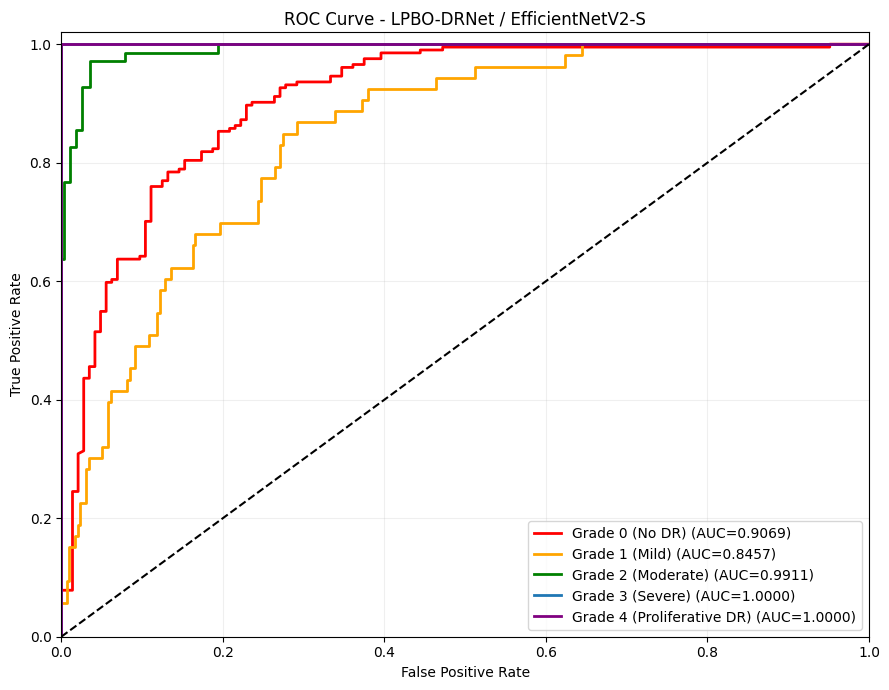

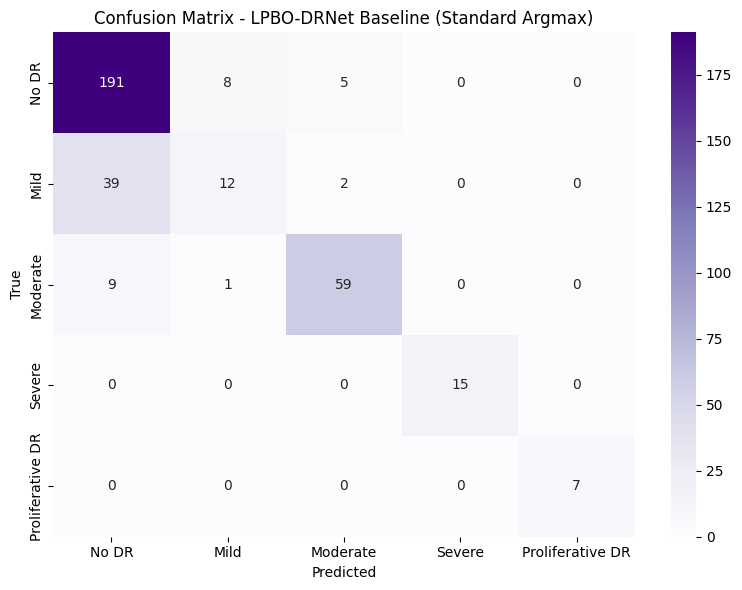

In [12]:
# ==============================================
# CELL 11 - Standard Ordinal Clean Test Evaluation
# ==============================================
ckpt = safe_torch_load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded validation-selected primary checkpoint: {BEST_MODEL_PATH.name}')
print(f'  epoch={ckpt["epoch"]}  val_acc={ckpt["best_val_acc"]*100:.2f}%  '
      f'val_qwk={ckpt["best_val_qwk"]:.4f}  val_loss={ckpt["best_val_loss"]:.5f}  '
      f'EMA={ckpt.get("used_ema", False)}')
print('  selection rule: val_acc -> val_qwk -> val_loss')
print('  Test is evaluated only after validation selection.')

@torch.no_grad()
def predict_outputs(model, loader):
    model.eval()
    labels_all, probs_all, boundary_all = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        with amp_autocast():
            probs, boundary_logits = model.predict_outputs(imgs)
        probs_all.extend(probs.cpu().numpy())
        boundary_all.extend(torch.sigmoid(boundary_logits).cpu().numpy())
        labels_all.extend(labels.cpu().tolist())
    y_true = np.array(labels_all)
    y_prob = np.array(probs_all)
    y_boundary = np.array(boundary_all)
    return y_true, y_prob.argmax(1), y_prob, y_boundary


def compute_auc(y_true, y_prob):
    try:
        return roc_auc_score(
            label_binarize(y_true, classes=list(range(NUM_CLASSES))),
            y_prob, multi_class='ovr', average='macro')
    except ValueError:
        return float('nan')


def per_class_auc(y_true, y_prob):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    aucs = {}
    for cls_idx in range(NUM_CLASSES):
        if len(np.unique(y_bin[:, cls_idx])) < 2:
            aucs[cls_idx] = float('nan')
        else:
            aucs[cls_idx] = roc_auc_score(y_bin[:, cls_idx], y_prob[:, cls_idx])
    return aucs


def plot_multiclass_roc(y_true, y_prob, title):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    colors = ['red', 'orange', 'green', 'tab:blue', 'purple']
    plt.figure(figsize=(9, 7))
    for cls_idx, color in zip(range(NUM_CLASSES), colors):
        if len(np.unique(y_bin[:, cls_idx])) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, cls_idx], y_prob[:, cls_idx])
        cls_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'Grade {cls_idx} ({CLASS_NAMES[cls_idx]}) (AUC={cls_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.02])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def expected_rank(y_prob):
    ranks = np.arange(NUM_CLASSES, dtype=np.float32)
    return (y_prob * ranks).sum(axis=1)


def apply_thresholds(y_prob, thresholds):
    scores = expected_rank(y_prob)
    return np.digitize(scores, np.asarray(thresholds, dtype=np.float32))


def tune_ordinal_thresholds(y_true, y_prob, metric='qwk'):
    thresholds = np.array([0.5, 1.5, 2.5, 3.5], dtype=np.float32)

    def score_fn(thr):
        pred = apply_thresholds(y_prob, thr)
        if metric == 'acc':
            return accuracy_score(y_true, pred)
        return cohen_kappa_score(y_true, pred, weights='quadratic')

    best_score = score_fn(thresholds)
    for span, step in [(0.70, 0.05), (0.30, 0.02), (0.12, 0.01)]:
        improved = True
        while improved:
            improved = False
            for i in range(NUM_CLASSES - 1):
                left = 0.05 if i == 0 else thresholds[i - 1] + 0.05
                right = (NUM_CLASSES - 1 - 0.05
                         if i == NUM_CLASSES - 2
                         else thresholds[i + 1] - 0.05)
                lo = max(left, thresholds[i] - span)
                hi = min(right, thresholds[i] + span)
                for val in np.arange(lo, hi + 1e-9, step):
                    cand = thresholds.copy()
                    cand[i] = val
                    cand_score = score_fn(cand)
                    if cand_score > best_score + 1e-7:
                        thresholds = cand
                        best_score = cand_score
                        improved = True
    return thresholds, best_score


def apply_bao_correction(y_prob, y_boundary,
                         mode='conservative', margin=0.20,
                         confidence=0.92):
    pred = y_prob.argmax(1).copy()
    sorted_idx = np.argsort(y_prob, axis=1)
    top1 = sorted_idx[:, -1]
    top2 = sorted_idx[:, -2]
    top1_prob = y_prob[np.arange(len(y_prob)), top1]
    top2_prob = y_prob[np.arange(len(y_prob)), top2]
    top_margin = top1_prob - top2_prob

    for i in range(len(pred)):
        c1, c2 = int(top1[i]), int(top2[i])
        allow = False
        if abs(c1 - c2) == 1 and top_margin[i] <= margin:
            allow = True
            b = min(c1, c2)
        elif mode == 'aggressive' and top1_prob[i] <= confidence:
            er = float(expected_rank(y_prob[i:i+1])[0])
            b = int(np.clip(np.floor(er), 0, NUM_CLASSES - 2))
            allow = True
        if allow:
            pred[i] = b + 1 if y_boundary[i, b] >= 0.5 else b
    return pred


def print_metrics(title, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    auc = compute_auc(y_true, y_prob)
    class_auc = per_class_auc(y_true, y_prob)
    print()
    print(f'{title} Accuracy : {acc*100:.2f}%')
    print(f'{title} Kappa    : {kappa:.4f}')
    print(f'{title} AUC      : {auc:.4f}')
    print(f'{title} AUC per class:')
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        print(f'  Grade {cls_idx} ({cls_name}): {class_auc[cls_idx]:.4f}')
    print()
    print(f'{title} classification report:')
    print(classification_report(y_true, y_pred,
          target_names=CLASS_NAMES, digits=4))
    return acc, kappa, auc


val_true, val_argmax_pred, val_prob, val_boundary = predict_outputs(model, val_loader)
y_true, y_pred, y_prob, y_boundary = predict_outputs(model, test_loader)

tuned_thresholds, tuned_val_score = tune_ordinal_thresholds(
    val_true, val_prob, metric=THRESHOLD_TUNE_METRIC)
y_val_tuned_pred = apply_thresholds(val_prob, tuned_thresholds)

y_val_bao_pred = apply_bao_correction(
    val_prob, val_boundary, mode=BAO_CORRECTION_MODE,
    margin=BAO_MARGIN, confidence=BAO_CONFIDENCE)
val_argmax_acc = accuracy_score(val_true, val_argmax_pred)
val_tuned_acc = accuracy_score(val_true, y_val_tuned_pred)
val_bao_acc = accuracy_score(val_true, y_val_bao_pred)
val_argmax_qwk = cohen_kappa_score(val_true, val_argmax_pred, weights='quadratic')
val_tuned_qwk = cohen_kappa_score(val_true, y_val_tuned_pred, weights='quadratic')
val_bao_qwk = cohen_kappa_score(val_true, y_val_bao_pred, weights='quadratic')

print('Validation checks:')
print(f'  threshold metric : {THRESHOLD_TUNE_METRIC}')
print(f'  thresholds       : {np.round(tuned_thresholds, 3).tolist()}')
print(f'  BAO mode         : {BAO_CORRECTION_MODE}  margin={BAO_MARGIN}  confidence={BAO_CONFIDENCE}')
print(f'  val argmax acc   : {val_argmax_acc*100:.2f}%  qwk={val_argmax_qwk:.4f}')
print(f'  val tuned acc    : {val_tuned_acc*100:.2f}%  qwk={val_tuned_qwk:.4f}')
print(f'  val BAO acc      : {val_bao_acc*100:.2f}%  qwk={val_bao_qwk:.4f}')

# Standard ordinal argmax is fixed before clean-test evaluation.
# Threshold and BAO variants above remain validation diagnostics only.
test_acc, test_kappa, test_auc = print_metrics(
    'Standard Argmax Test', y_true, y_pred, y_prob)

plot_multiclass_roc(y_true, y_prob, 'ROC Curve - LPBO-DRNet / EfficientNetV2-S')

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - LPBO-DRNet Baseline (Standard Argmax)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()



Validation-selected checkpoint probability ensemble
Candidate checkpoints: 5
  [0] top_ep031        ep=031 val_acc=84.77% val_qwk=0.9067 val_loss=0.34703
  [1] top_ep032        ep=032 val_acc=84.77% val_qwk=0.9067 val_loss=0.35998
  [2] top_ep033        ep=033 val_acc=84.48% val_qwk=0.9054 val_loss=0.37183
  [3] top_ep030        ep=030 val_acc=84.20% val_qwk=0.9040 val_loss=0.33436
  [4] top_ep029        ep=029 val_acc=83.62% val_qwk=0.9015 val_loss=0.32244

Top validation ensembles:
                        names  size  val_acc  val_qwk  val_auc  mean_val_loss
          top_ep031+top_ep029     2 0.850575 0.912024 0.945915       0.334739
          top_ep032+top_ep029     2 0.850575 0.912024 0.945827       0.341215
          top_ep033+top_ep029     2 0.847701 0.906889 0.945973       0.347135
          top_ep033+top_ep030     2 0.847701 0.906655 0.945992       0.353091
top_ep031+top_ep032+top_ep030     3 0.847701 0.906655 0.945927       0.347125
top_ep031+top_ep033+top_ep030     3 0.8477

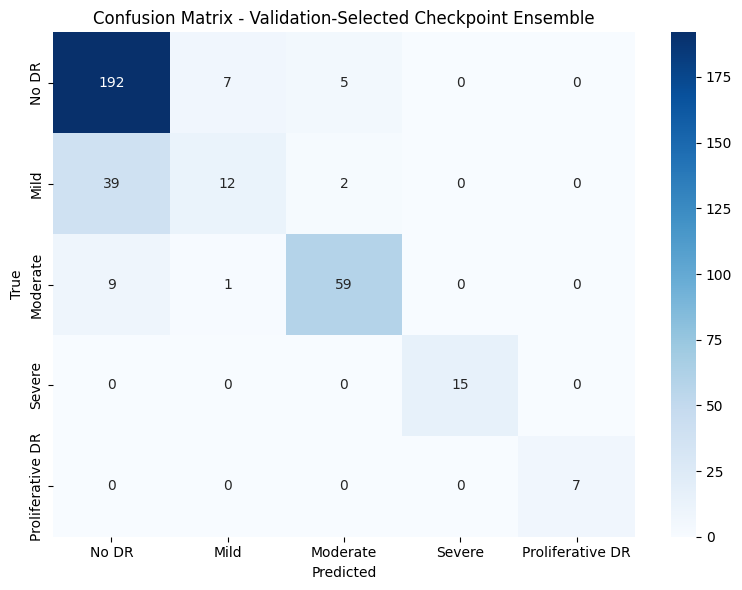

LPBOBoundaryConditionedNet(
  (backbone): LPBOBackboneAdapter(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        

In [13]:
# ==============================================
# CELL 11B - Validation-Selected Checkpoint Probability Ensemble
# ==============================================
from itertools import combinations

print('\n' + '=' * 70)
print('Validation-selected checkpoint probability ensemble')
print('=' * 70)

candidate_meta = []
if 'top_ensemble_records' in globals() and len(top_ensemble_records):
    for rec in top_ensemble_records:
        candidate_meta.append({
            'name': f"top_ep{int(rec['epoch']):03d}",
            'path': Path(rec['path']),
            'epoch': int(rec['epoch']),
            'val_loss': float(rec['val_loss']),
            'val_acc': float(rec['val_acc']),
            'val_qwk': float(rec['val_qwk']),
        })
elif (OUTPUT_DIR / 'top_ensemble_checkpoints.csv').exists():
    top_df = pd.read_csv(OUTPUT_DIR / 'top_ensemble_checkpoints.csv')
    for _, rec in top_df.iterrows():
        candidate_meta.append({
            'name': f"top_ep{int(rec['epoch']):03d}",
            'path': Path(rec['path']),
            'epoch': int(rec['epoch']),
            'val_loss': float(rec['val_loss']),
            'val_acc': float(rec['val_acc']),
            'val_qwk': float(rec['val_qwk']),
        })

# Include the canonical validation-best checkpoints as fallbacks.
for name, path in [
    ('best_val_loss', BEST_LOSS_PATH),
    ('best_val_acc', BEST_ACC_PATH),
    ('best_val_qwk', BEST_QWK_PATH),
    ('selected_primary', BEST_MODEL_PATH),
]:
    if path.exists():
        meta = safe_torch_load(path, map_location='cpu')
        candidate_meta.append({
            'name': name,
            'path': path,
            'epoch': int(meta.get('epoch', -1)),
            'val_loss': float(meta.get('best_val_loss', np.nan)),
            'val_acc': float(meta.get('best_val_acc', np.nan)),
            'val_qwk': float(meta.get('best_val_qwk', np.nan)),
        })

# Deduplicate by epoch and validation metrics, preferring top_ep names when present.
unique = {}
for rec in candidate_meta:
    if not rec['path'].exists():
        continue
    key = (rec['epoch'], round(rec['val_acc'], 8), round(rec['val_qwk'], 8), round(rec['val_loss'], 8))
    if key not in unique or rec['name'].startswith('top_ep'):
        unique[key] = rec
candidate_meta = sorted(
    unique.values(),
    key=lambda r: (r['val_acc'], r['val_qwk'], -r['val_loss']),
    reverse=True,
)[:ENSEMBLE_TOP_N]

print(f'Candidate checkpoints: {len(candidate_meta)}')
for i, rec in enumerate(candidate_meta):
    print(f"  [{i}] {rec['name']:<16} ep={rec['epoch']:03d} "
          f"val_acc={rec['val_acc']*100:.2f}% val_qwk={rec['val_qwk']:.4f} "
          f"val_loss={rec['val_loss']:.5f}")

if len(candidate_meta) < 2:
    print('Not enough distinct checkpoints for ensemble; keeping standard checkpoint result.')
    ensemble_selected_names = [candidate_meta[0]['name']] if candidate_meta else []
    ensemble_y_prob = y_prob.copy()
    ensemble_y_boundary = y_boundary.copy()
    ensemble_y_pred = y_pred.copy()
    ensemble_test_acc, ensemble_test_kappa, ensemble_test_auc = test_acc, test_kappa, test_auc
else:
    val_preds, test_preds = [], []
    for rec in candidate_meta:
        ck = safe_torch_load(rec['path'], map_location=device)
        model.load_state_dict(ck['model_state'])
        vt, _, vp, vb = predict_outputs(model, val_loader)
        tt, _, tp, tb = predict_outputs(model, test_loader)
        if not np.array_equal(vt, val_true) or not np.array_equal(tt, y_true):
            raise RuntimeError('Loader label order changed during ensemble prediction.')
        val_preds.append({'prob': vp, 'boundary': vb})
        test_preds.append({'prob': tp, 'boundary': tb})

    rows = []
    n = len(candidate_meta)
    max_size = min(ENSEMBLE_MAX_SIZE, n)
    for size in range(2, max_size + 1):
        for idxs in combinations(range(n), size):
            avg_prob = np.mean([val_preds[i]['prob'] for i in idxs], axis=0)
            avg_boundary = np.mean([val_preds[i]['boundary'] for i in idxs], axis=0)
            pred = avg_prob.argmax(1)
            rows.append({
                'idxs': idxs,
                'names': '+'.join(candidate_meta[i]['name'] for i in idxs),
                'size': size,
                'val_acc': accuracy_score(val_true, pred),
                'val_qwk': cohen_kappa_score(val_true, pred, weights='quadratic'),
                'val_auc': compute_auc(val_true, avg_prob),
                'mean_val_loss': float(np.mean([candidate_meta[i]['val_loss'] for i in idxs])),
            })

    ens_df = pd.DataFrame(rows).sort_values(
        ['val_acc', 'val_qwk', 'val_auc', 'size', 'mean_val_loss'],
        ascending=[False, False, False, True, True],
    ).reset_index(drop=True)
    ens_df.drop(columns=['idxs']).to_csv(OUTPUT_DIR / 'ensemble_validation_candidates.csv', index=False)
    print('\nTop validation ensembles:')
    print(ens_df.drop(columns=['idxs']).head(10).to_string(index=False))

    best_ens = ens_df.iloc[0]
    selected_idxs = tuple(best_ens['idxs'])
    ensemble_selected_names = [candidate_meta[i]['name'] for i in selected_idxs]
    ensemble_y_prob = np.mean([test_preds[i]['prob'] for i in selected_idxs], axis=0)
    ensemble_y_boundary = np.mean([test_preds[i]['boundary'] for i in selected_idxs], axis=0)
    ensemble_y_pred = ensemble_y_prob.argmax(1)

    print('\nSelected ensemble by validation only:')
    print(f"  names   : {' + '.join(ensemble_selected_names)}")
    print(f"  val_acc : {best_ens['val_acc']*100:.2f}%")
    print(f"  val_qwk : {best_ens['val_qwk']:.4f}")
    print(f"  val_auc : {best_ens['val_auc']:.4f}")

    ensemble_test_acc, ensemble_test_kappa, ensemble_test_auc = print_metrics(
        'Checkpoint Ensemble Test', y_true, ensemble_y_pred, ensemble_y_prob)

    print('Comparison against selected single checkpoint:')
    print(f'  Single checkpoint acc : {test_acc*100:.2f}% ({(1-test_acc)*len(y_true):.0f} errors approx.)')
    print(f'  Ensemble acc          : {ensemble_test_acc*100:.2f}% ({(1-ensemble_test_acc)*len(y_true):.0f} errors approx.)')
    print(f'  Delta acc             : {(ensemble_test_acc-test_acc)*100:+.2f} percentage points')

    cm_ens = confusion_matrix(y_true, ensemble_y_pred, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix - Validation-Selected Checkpoint Ensemble')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

# Restore the selected primary checkpoint for any later cells.
primary_ckpt = safe_torch_load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(primary_ckpt['model_state'])
model.eval()


In [14]:
# ==============================================
# CELL 12 - Error Analysis
# ==============================================

def build_error_table(df, y_true, y_pred, y_prob, prefix='standard'):
    conf = y_prob.max(axis=1)
    sorted_prob = np.sort(y_prob, axis=1)
    margin = sorted_prob[:, -1] - sorted_prob[:, -2]
    true_prob = y_prob[np.arange(len(y_true)), y_true]
    pred_prob = y_prob[np.arange(len(y_pred)), y_pred]
    out = df.copy().reset_index(drop=True)
    out['true'] = y_true
    out['pred'] = y_pred
    out['correct'] = out['true'] == out['pred']
    out['confidence'] = conf
    out['margin'] = margin
    out['true_prob'] = true_prob
    out['pred_prob'] = pred_prob
    out['error_type'] = out['true'].astype(str) + '->' + out['pred'].astype(str)
    out.to_csv(OUTPUT_DIR / f'test_predictions_{prefix}.csv', index=False)
    out[~out['correct']].to_csv(OUTPUT_DIR / f'test_errors_{prefix}.csv', index=False)
    return out[~out['correct']].copy()


err_df = build_error_table(test_df, y_true, y_pred, y_prob, prefix='standard_argmax')
print(f'\nStandard Argmax errors: {len(err_df)} / {len(test_df)}')
if len(err_df):
    print('\nError type counts:')
    print(err_df['error_type'].value_counts())
    print('\nErrors by true class:')
    print(err_df['true'].value_counts().sort_index())
    print('\nLowest-margin errors:')
    cols = ['id_code', 'true', 'pred', 'confidence', 'margin',
            'true_prob', 'pred_prob', 'image_path']
    show_cols = [c for c in cols if c in err_df.columns]
    print(err_df.sort_values('margin').head(25)[show_cols].to_string(index=False))

if 'ensemble_y_pred' in globals():
    ens_err_df = build_error_table(
        test_df, y_true, ensemble_y_pred, ensemble_y_prob,
        prefix='checkpoint_ensemble')
    print(f'\nCheckpoint Ensemble errors: {len(ens_err_df)} / {len(test_df)}')
    if len(ens_err_df):
        print('\nEnsemble error type counts:')
        print(ens_err_df['error_type'].value_counts())
        print('\nEnsemble errors by true class:')
        print(ens_err_df['true'].value_counts().sort_index())

print('\nTTA disabled. Error analysis uses standard ordinal argmax only. Ensemble selection uses validation only.')



Standard Argmax errors: 64 / 348

Error type counts:
error_type
1->0    39
2->0     9
0->1     8
0->2     5
1->2     2
2->1     1
Name: count, dtype: int64

Errors by true class:
true
0    13
1    41
2    10
Name: count, dtype: int64

Lowest-margin errors:
                   id_code  true  pred  confidence   margin  true_prob  pred_prob                                                                                                    image_path
              IM001300.JPG     0     1    0.517908 0.035980   0.481928   0.517908               /kaggle/input/datasets/annindie/messidor/Messidor/messidor-2/messidor-2/preprocess/IM001300.JPG
              IM001477.JPG     2     0    0.540802 0.081646   0.459156   0.540802               /kaggle/input/datasets/annindie/messidor/Messidor/messidor-2/messidor-2/preprocess/IM001477.JPG
20060523_49269_0100_PP.png     1     0    0.600823 0.202016   0.398807   0.600823 /kaggle/input/datasets/annindie/messidor/Messidor/messidor-2/messidor-2/preprocess/2

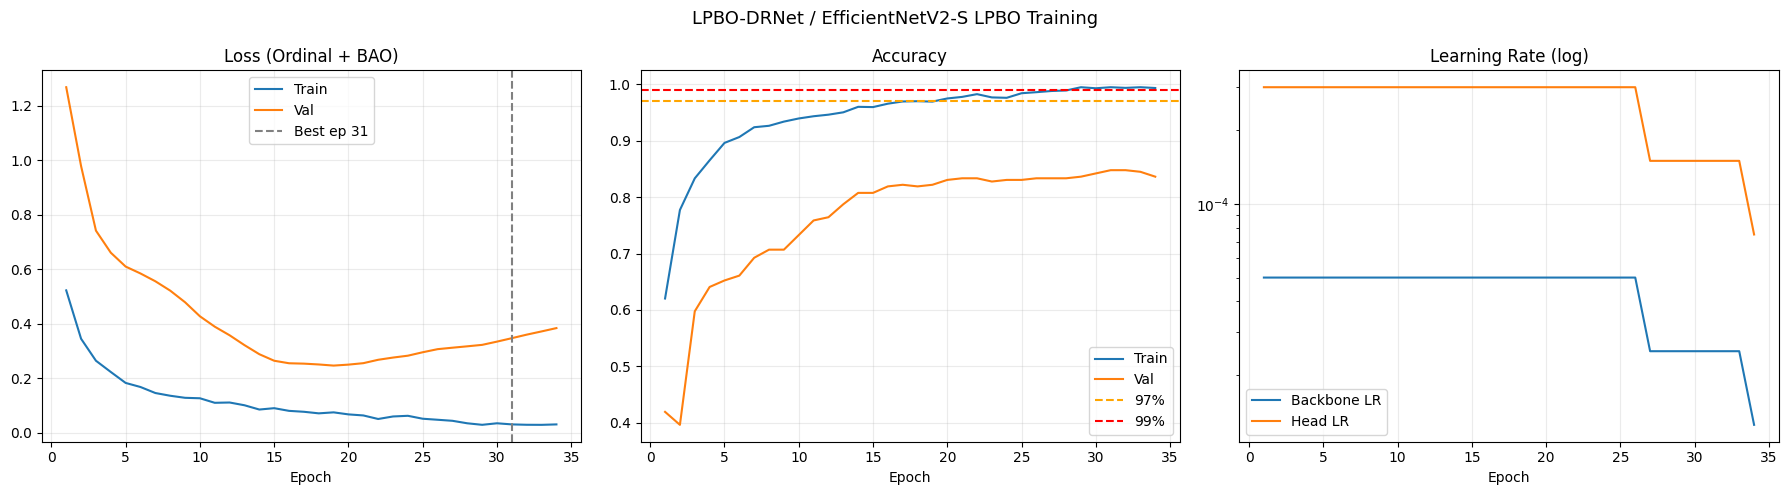

  EXPERIMENT 1: BndFocal γ=1.5 + Strong BndWeights + Phase-2 Real Fine-tune
  Standard Test Acc     : 81.61%
  Standard Test Kappa   : 0.8615
  Standard Test AUC     : 0.9487
  Input resolution      : 320 x 320
  Boundary focal gamma  : 2.0 (BCE-equivalent baseline)
  Boundary pair weights : [2.0, 2.5, 2.0, 1.5]
  Ensemble Test Acc     : 81.90%
  Ensemble Test Kappa   : 0.8629
  Ensemble Test AUC     : 0.9451
  Ensemble checkpoints  : top_ep031 + top_ep029
  Selected epoch        : 31
  Checkpoint selection  : val_acc -> val_qwk -> val_loss
  Primary inference     : standard ordinal argmax
  Gap to >98%: 16.10 percentage points

TTA disabled. No test sample is excluded after splitting.


In [15]:
# ==============================================
# CELL 13 - Curves + Final Summary
# ==============================================
epochs = np.arange(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LPBO-DRNet / EfficientNetV2-S LPBO Training', fontsize=13)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'], label='Val')
axes[0].axvline(best_epoch, color='gray', ls='--', label=f'Best ep {best_epoch}')
axes[0].set_title('Loss (Ordinal + BAO)')
axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'], label='Val')
axes[1].axhline(0.97, color='orange', ls='--', label='97%')
axes[1].axhline(0.99, color='red', ls='--', label='99%')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.25)

axes[2].plot(epochs, history['bb_lr'], label='Backbone LR')
axes[2].plot(epochs, history['head_lr'], label='Head LR')
axes[2].set_title('Learning Rate (log)')
axes[2].set_xlabel('Epoch'); axes[2].set_yscale('log')
axes[2].legend(); axes[2].grid(alpha=0.25)

plt.tight_layout(); plt.show()

print('=' * 60)
print('  EXPERIMENT 1: BndFocal γ=1.5 + Strong BndWeights + Phase-2 Real Fine-tune')
print('=' * 60)
print(f'  Standard Test Acc     : {test_acc*100:.2f}%')
print(f'  Standard Test Kappa   : {test_kappa:.4f}')
print(f'  Standard Test AUC     : {test_auc:.4f}')
print(f'  Input resolution      : {IMAGE_SIZE} x {IMAGE_SIZE}')
print(f'  Boundary focal gamma  : {BOUNDARY_FOCAL_GAMMA} (BCE-equivalent baseline)')
print(f'  Boundary pair weights : {BOUNDARY_PAIR_WEIGHTS}')
if 'ensemble_test_acc' in globals():
    print(f'  Ensemble Test Acc     : {ensemble_test_acc*100:.2f}%')
    print(f'  Ensemble Test Kappa   : {ensemble_test_kappa:.4f}')
    print(f'  Ensemble Test AUC     : {ensemble_test_auc:.4f}')
    print(f"  Ensemble checkpoints  : {' + '.join(ensemble_selected_names)}")
print(f'  Selected epoch        : {best_epoch}')
print('  Checkpoint selection  : val_acc -> val_qwk -> val_loss')
print('  Primary inference     : standard ordinal argmax')
print('=' * 60)
best_report_acc = ensemble_test_acc if 'ensemble_test_acc' in globals() else test_acc
if best_report_acc > 0.98:
    print(f'  Target >98% reached: {best_report_acc*100:.2f}%')
else:
    print(f'  Gap to >98%: {(0.98 - best_report_acc)*100:.2f} percentage points')
print()
print('TTA disabled. No test sample is excluded after splitting.')


In [16]:
# ==============================================
# Dataset-mode note
# ==============================================
print('Dataset-mode setup:')
print(f'  DATA_MODE       : {DATA_MODE}')
print(f'  Train size      : {len(train_df)}')
print(f'  Val size        : {len(val_df)}')
print(f'  Test size       : {len(test_df)}')
print(f'  Train sources   : {train_df["source"].value_counts().to_dict()}')
print('  Evaluation note : metrics are computed on the full clean test split for the selected DATA_MODE.')
print('  TTA             : disabled.')


Dataset-mode setup:
  DATA_MODE       : messidor_gan
  Train size      : 4317
  Val size        : 348
  Test size       : 348
  Train sources   : {'gan_messidor': 3273, 'messidor': 1044}
  Evaluation note : metrics are computed on the full clean test split for the selected DATA_MODE.
  TTA             : disabled.
